In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from collections import Counter
from wordcloud import WordCloud
import string
import random
import warnings
warnings.filterwarnings("ignore")

import nltk
nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)
nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Paleta de colores
COLOR_SPAM = "#E74C3C"
COLOR_HAM  = "#2ECC71"

print("✓ Librerías cargadas correctamente.")

✓ Librerías cargadas correctamente.


---
## 1. 

HAM: Son mensajes legítimos que el destinatario desea recibir. El término "ham" se usa por contraste con "spam".

SPAM: Son mensajes no solicitados, generalmente de carácter comercial, fraudulento o malicioso, enviados masivamente sin el consentimiento del receptor.

Diferenciar spam de ham es esencial para proteger a los usuarios de fraudes, phishing y publicidad no deseada. Los clasificadores automáticos (p. ej. Naive Bayes, SVM, redes neuronales) aprenden patrones lingüísticos del texto para tomar esta decisión de forma eficiente y escalable, sin intervención humana por mensaje.


---
## 2. Carga y Exploración de Datos (EDA)


In [4]:
# ── 2.1 Cargar dataset ──────────────────────────────────────────────────────
df = pd.read_csv(
    "spam_ham.csv",
    encoding="latin-1",
    sep="\t",
    header=0,
    engine="python",
    on_bad_lines="skip"
)

# Si con tabulador no funciona, leer línea por línea manualmente
if df.shape[1] < 2:
    rows = []
    with open("spam_ham.csv", encoding="latin-1") as f:
        next(f)  # saltar encabezado
        for line in f:
            line = line.strip()
            if "\t" in line:
                label, message = line.split("\t", 1)  # split solo en el PRIMER tabulador
            else:
                parts = line.split(",", 1)             # split solo en la PRIMERA coma
                if len(parts) == 2:
                    label, message = parts
                else:
                    continue
            rows.append({"label": label.strip().lower(), "message": message.strip()})
    df = pd.DataFrame(rows)
else:
    df.columns = ["label", "message"]
    df["label"] = df["label"].str.strip().str.lower()
    df["message"] = df["message"].astype(str)

df["length"] = df["message"].apply(len)

print(f"Dimensiones del dataset : {df.shape}")
print(f"Etiquetas únicas        : {df['label'].unique()}")
print(f"\nCantidad total de mensajes: {len(df)}")
print(df["label"].value_counts().to_string())

display(df.head(10))

Dimensiones del dataset : (1247, 3)
Etiquetas únicas        : ['ham;go until jurong point' "ham;nah i don't think he goes to usf"
 "spam;freemsg hey there darling it's been 3 week's now and no word back! i'd like some fun you up for it still? tb ok! xxx std chgs to send"
 "ham;i'm gonna be home soon and i don't want to talk about this stuff anymore tonight"
 'spam;six chances to win cash! from 100 to 20'
 'spam;urgent! you have won a 1 week free membership in our å£100'
 'spam;xxxmobilemovieclub: to use your credit'
 'spam;england v macedonia - dont miss the goals/team news. txt ur national team to 87077 eg england to 87077 try:wales'
 "ham;wait that's still not all that clear" 'ham;oops'
 'ham;did i forget to tell you ? i want you' 'ham;fair enough'
 'ham;yeah hopefully'
 'spam;congrats! 1 year special cinema pass for 2 is yours. call 09061209465 now! c suprman v'
 'ham;sorry' 'ham;sorry my roommates took forever'
 'spam;as a valued customer'
 'spam;urgent ur awarded a complimentary t

,label,message,length
0,ham;go until jurong point,crazy.. Available only in bugis n great world ...,88
1,ham;nah i don't think he goes to usf,he lives around here though,27
2,spam;freemsg hey there darling it's been 3 wee...,å£1.50 to rcv,13
3,ham;i'm gonna be home soon and i don't want to...,k? I've cried enough today.,27
4,spam;six chances to win cash! from 100 to 20,000 pounds txt> CSH11 and send to 87575. Cost ...,96
5,spam;urgent! you have won a 1 week free member...,000 Prize Jackpot! Txt the word: CLAIM to No: ...,97
6,spam;xxxmobilemovieclub: to use your credit,click the WAP link in the next txt message or ...,109
7,spam;england v macedonia - dont miss the goals...,SCOTLAND 4txt/Ì¼1.20 POBOXox36504W45WQ 16+,42
8,ham;wait that's still not all that clear,were you not sure about me being sarcastic or ...,92
9,ham;oops,I'll let you know when my roommate's done,41


In [5]:
# ── 2.2 Cinco mensajes aleatorios ───────────────────────────────────────────
print("── 5 mensajes aleatorios ──")
sample_idx = random.sample(range(len(df)), 5)
for i, idx in enumerate(sample_idx, 1):
    row = df.iloc[idx]
    print(f"\n[{i}] Label: {row['label'].upper()}")
    print(f"    Mensaje: {row['message'][:120]}{'...' if len(row['message']) > 120 else ''}")

── 5 mensajes aleatorios ──

[1] Label: HAM;WEN UR LOVABLE BCUMS ANGRY WID U
    Mensaje: dnt take it seriously.. Coz being angry is d most childish n true way of showing deep affection, care n luv!.. kettoda m...

[2] Label: HAM;CARLOS TOOK A WHILE (AGAIN)
    Mensaje: we leave in a minute

[3] Label: HAM;DADDY
    Mensaje: shu shu is looking 4 u... U wan me 2 tell him u're not in singapore or wat?

[4] Label: HAM;PETE
    Mensaje: is this your phone still? Its Jenny from college and Leanne.what are you up to now?:)

[5] Label: HAM;CALL ME DA
    Mensaje: i am waiting for your call.


In [7]:
# Diagnóstico rápido
print(df["label"].unique())
print(df["label"].value_counts())
print(df["label"].dtype)

['ham;go until jurong point' "ham;nah i don't think he goes to usf"
 "spam;freemsg hey there darling it's been 3 week's now and no word back! i'd like some fun you up for it still? tb ok! xxx std chgs to send"
 "ham;i'm gonna be home soon and i don't want to talk about this stuff anymore tonight"
 'spam;six chances to win cash! from 100 to 20'
 'spam;urgent! you have won a 1 week free membership in our å£100'
 'spam;xxxmobilemovieclub: to use your credit'
 'spam;england v macedonia - dont miss the goals/team news. txt ur national team to 87077 eg england to 87077 try:wales'
 "ham;wait that's still not all that clear" 'ham;oops'
 'ham;did i forget to tell you ? i want you' 'ham;fair enough'
 'ham;yeah hopefully'
 'spam;congrats! 1 year special cinema pass for 2 is yours. call 09061209465 now! c suprman v'
 'ham;sorry' 'ham;sorry my roommates took forever'
 'spam;as a valued customer'
 'spam;urgent ur awarded a complimentary trip to eurodisinc trav'
 'ham;i call you later' 'ham;ela kano.

Mensajes spam: 1
Mensajes ham : 4


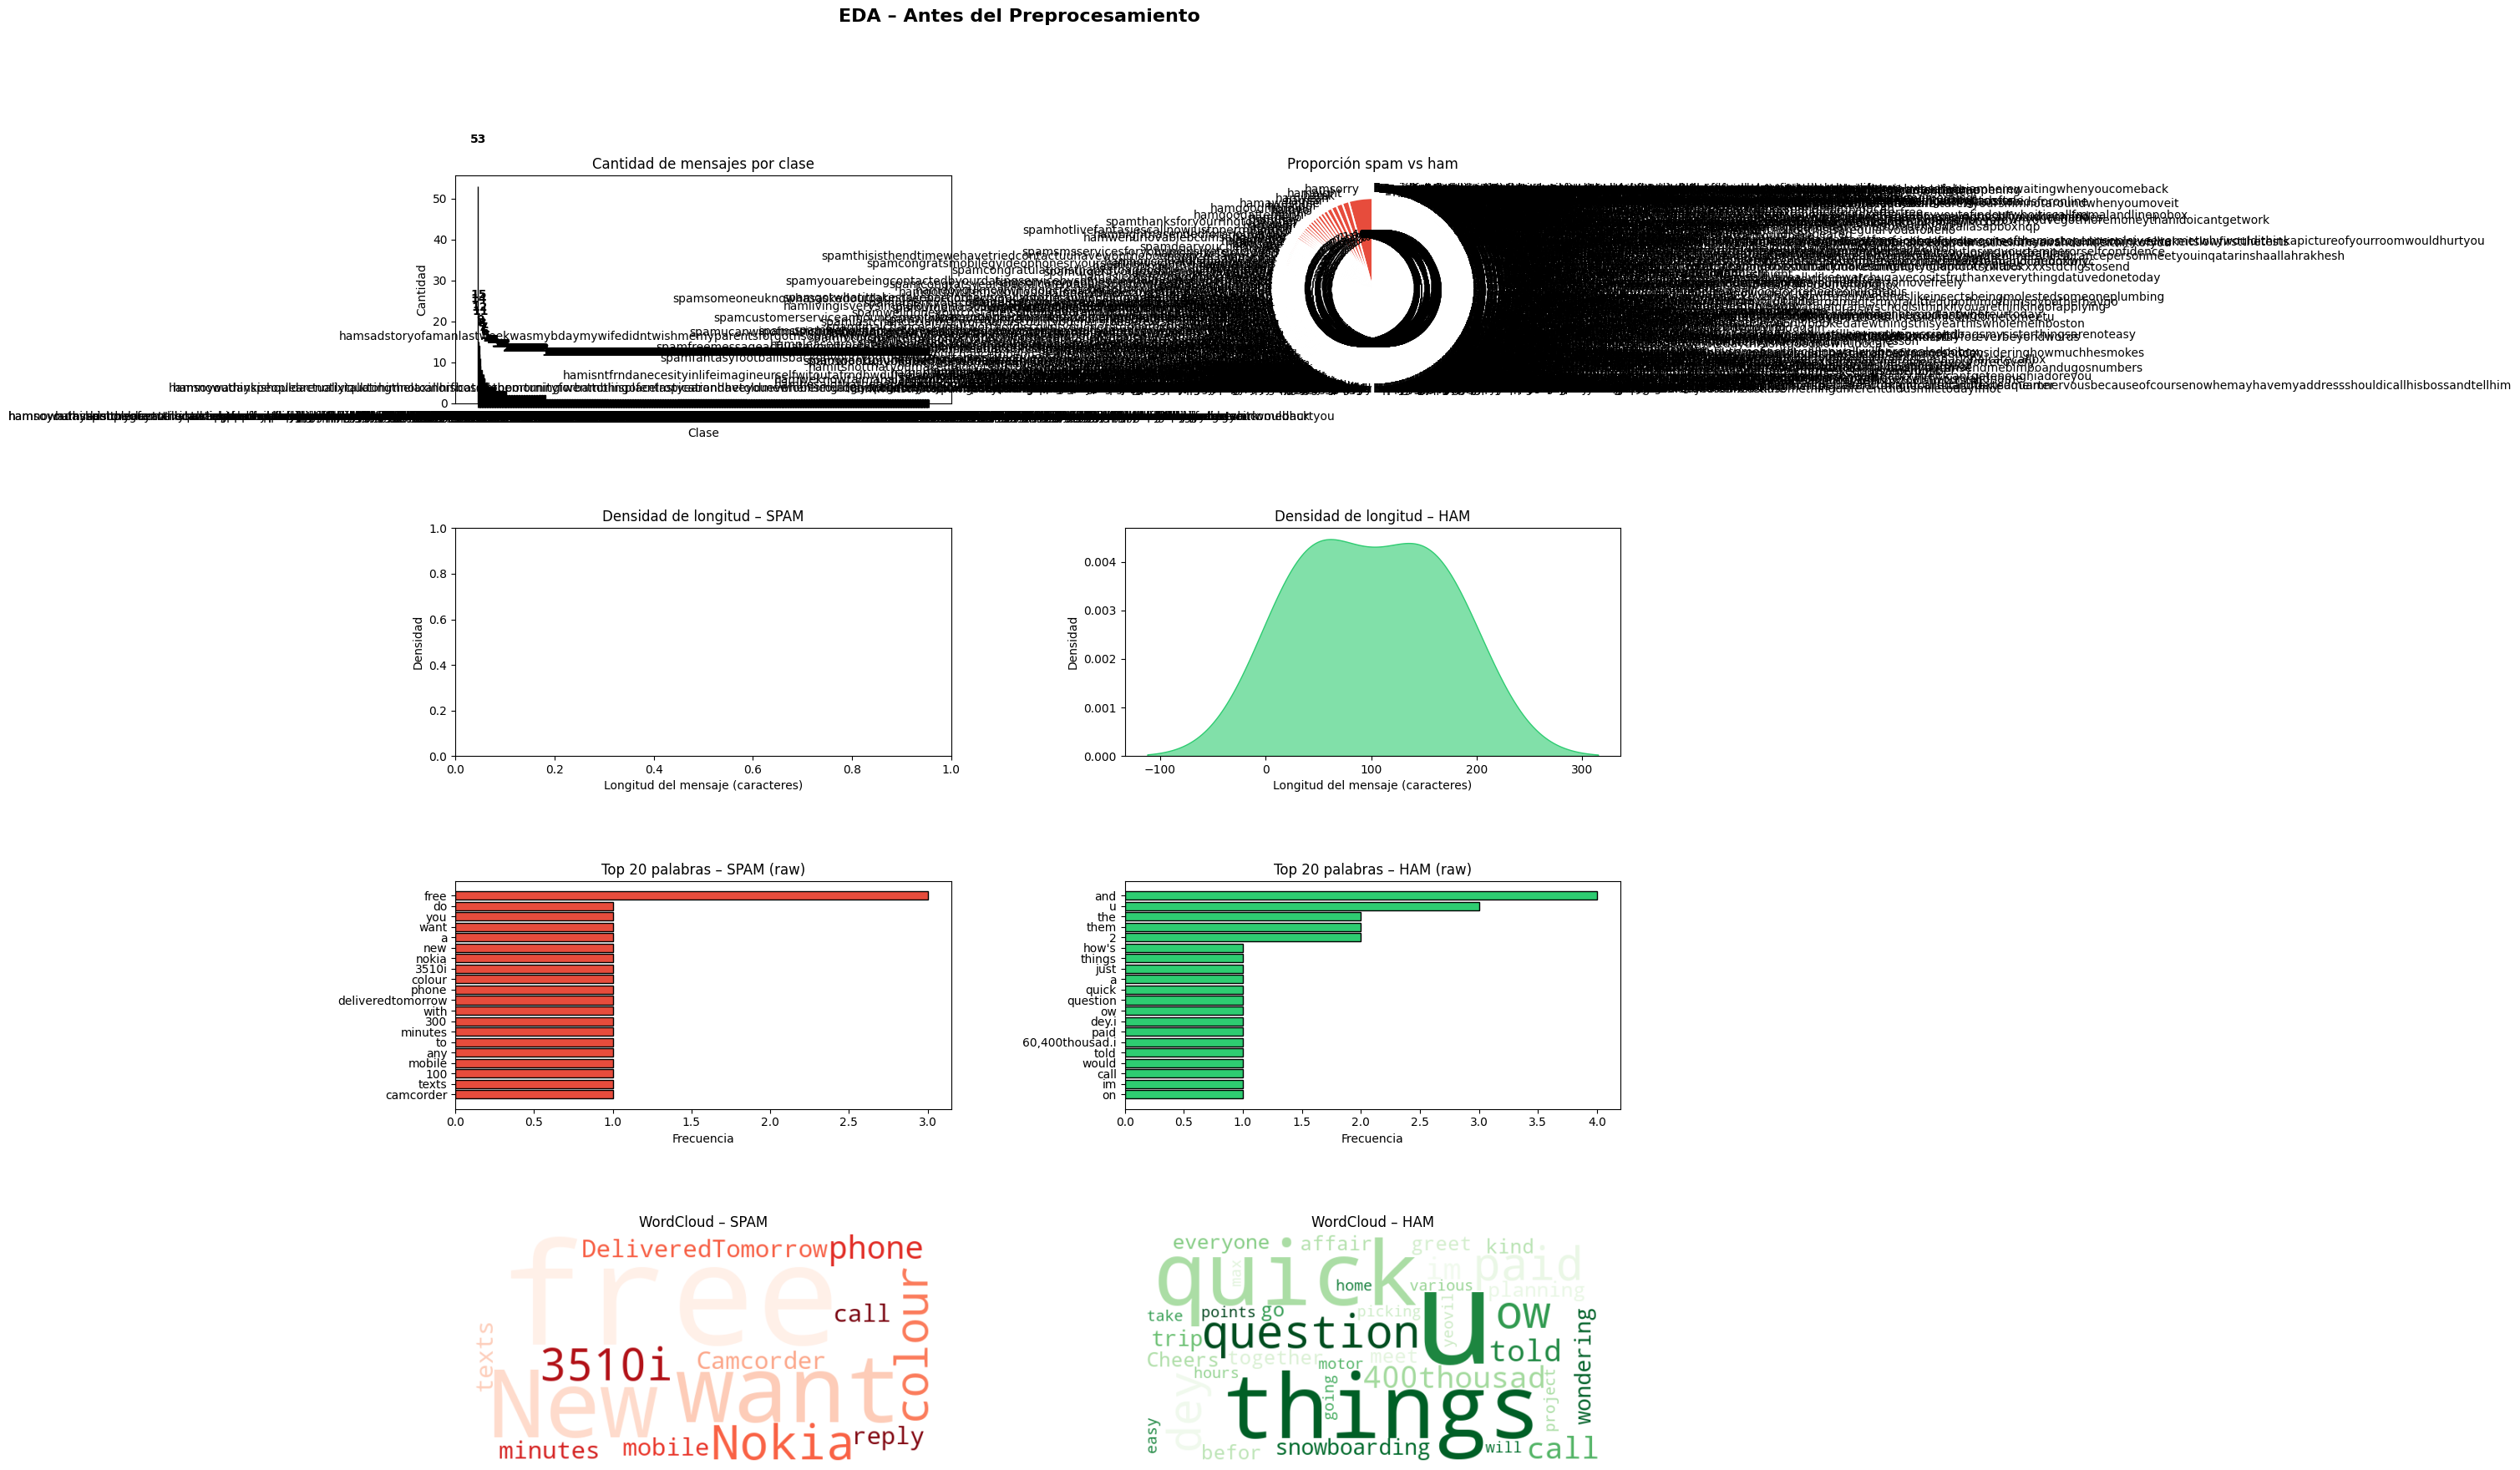


[✓] Figura 'eda_antes.png' guardada.


In [8]:
# ── 2.3 Visualizaciones EDA ─────────────────────────────────────────────────

# Limpieza extra de etiquetas por si quedaron caracteres ocultos
df["label"] = df["label"].str.strip().str.lower().str.replace(r"[^a-z]", "", regex=True)

spam_df = df[df["label"] == "spam"]
ham_df  = df[df["label"] == "ham"]

# Verificación
print(f"Mensajes spam: {len(spam_df)}")
print(f"Mensajes ham : {len(ham_df)}")
assert len(spam_df) > 0, "❌ spam_df está vacío — revisa las etiquetas"
assert len(ham_df)  > 0, "❌ ham_df está vacío — revisa las etiquetas"

fig = plt.figure(figsize=(18, 20))
fig.suptitle("EDA – Antes del Preprocesamiento", fontsize=16, fontweight="bold", y=0.98)
gs = gridspec.GridSpec(4, 2, figure=fig, hspace=0.55, wspace=0.35)

# (a) Cantidad total por clase
ax1 = fig.add_subplot(gs[0, 0])
counts = df["label"].value_counts()
bars = ax1.bar(counts.index, counts.values,
               color=[COLOR_HAM if l == "ham" else COLOR_SPAM for l in counts.index],
               edgecolor="black", width=0.5)
ax1.set_title("Cantidad de mensajes por clase")
ax1.set_xlabel("Clase")
ax1.set_ylabel("Cantidad")
for bar, v in zip(bars, counts.values):
    ax1.text(bar.get_x() + bar.get_width() / 2, v + 10, str(v),
             ha="center", va="bottom", fontweight="bold")

# (b) Proporción spam vs ham
ax2 = fig.add_subplot(gs[0, 1])
ax2.pie(counts.values, labels=counts.index, autopct="%1.1f%%",
        colors=[COLOR_HAM if l == "ham" else COLOR_SPAM for l in counts.index],
        startangle=90, wedgeprops={"edgecolor": "white", "linewidth": 1.5})
ax2.set_title("Proporción spam vs ham")

# (c) Densidad de longitud – spam
ax3 = fig.add_subplot(gs[1, 0])
sns.kdeplot(spam_df["length"], ax=ax3, fill=True, color=COLOR_SPAM, alpha=0.6)
ax3.set_title("Densidad de longitud – SPAM")
ax3.set_xlabel("Longitud del mensaje (caracteres)")
ax3.set_ylabel("Densidad")

# (d) Densidad de longitud – ham
ax4 = fig.add_subplot(gs[1, 1])
sns.kdeplot(ham_df["length"], ax=ax4, fill=True, color=COLOR_HAM, alpha=0.6)
ax4.set_title("Densidad de longitud – HAM")
ax4.set_xlabel("Longitud del mensaje (caracteres)")
ax4.set_ylabel("Densidad")

# Función auxiliar: top N palabras
def top_words(series, n=20):
    all_words = " ".join(series).lower().split()
    all_words = [w.strip(string.punctuation) for w in all_words if w.strip(string.punctuation)]
    return Counter(all_words).most_common(n)

# (e) Top 20 palabras – spam
ax5 = fig.add_subplot(gs[2, 0])
words_spam = top_words(spam_df["message"])
ax5.barh([w for w, _ in words_spam[::-1]], [c for _, c in words_spam[::-1]],
         color=COLOR_SPAM, edgecolor="black")
ax5.set_title("Top 20 palabras – SPAM (raw)")
ax5.set_xlabel("Frecuencia")

# (f) Top 20 palabras – ham
ax6 = fig.add_subplot(gs[2, 1])
words_ham = top_words(ham_df["message"])
ax6.barh([w for w, _ in words_ham[::-1]], [c for _, c in words_ham[::-1]],
         color=COLOR_HAM, edgecolor="black")
ax6.set_title("Top 20 palabras – HAM (raw)")
ax6.set_xlabel("Frecuencia")

# (g) WordCloud – spam
ax7 = fig.add_subplot(gs[3, 0])
text_spam = " ".join(spam_df["message"].dropna().astype(str))
wc_spam = WordCloud(width=600, height=300, background_color="white",
                    colormap="Reds", max_words=100)
wc_spam.generate(text_spam)
ax7.imshow(wc_spam, interpolation="bilinear")
ax7.axis("off")
ax7.set_title("WordCloud – SPAM")

# (h) WordCloud – ham
ax8 = fig.add_subplot(gs[3, 1])
text_ham = " ".join(ham_df["message"].dropna().astype(str))
wc_ham = WordCloud(width=600, height=300, background_color="white",
                   colormap="Greens", max_words=100)
wc_ham.generate(text_ham)
ax8.imshow(wc_ham, interpolation="bilinear")
ax8.axis("off")
ax8.set_title("WordCloud – HAM")

plt.savefig("eda_antes.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n[✓] Figura 'eda_antes.png' guardada.")

---
## 3. Preprocesamiento de Texto

Se aplica el siguiente pipeline con NLTK:

| Paso | Técnica | Por qué es útil |
|------|---------|-----------------|
| 1 | Tokenización | Divide el texto en unidades tokens para procesarlas individualmente |
| 2 | Minúsculas | Normaliza el vocabulario: Free y free son la misma palabra |
| 3 | Eliminar puntuación | Elimina ruido que no aporta significado semántico |
| 4 | Eliminar stopwords | Descarta palabras muy frecuentes pero poco informativas |
| 5 | Lematización | Reduce cada token a su forma canónica. Se prefiere sobre stemming porque produce palabras reales y preserva el significado semántico |


In [9]:
STOP_WORDS = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def preprocess(text: str) -> str:
    tokens = word_tokenize(text)                                      # 1. Tokenizar
    tokens = [t.lower() for t in tokens]                              # 2. Minúsculas
    tokens = [t for t in tokens if t.isalpha()]                       # 3. Solo letras (elimina puntuación y números)
    tokens = [t for t in tokens if t not in STOP_WORDS]              # 4. Eliminar stopwords
    tokens = [lemmatizer.lemmatize(t) for t in tokens]               # 5. Lematización
    return " ".join(tokens)

print("Aplicando preprocesamiento… (puede tardar unos segundos)")
df["processed"]   = df["message"].apply(preprocess)
df["proc_length"] = df["processed"].apply(len)

print("\n[✓] Preprocesamiento completado.")
print("\nEjemplo:")
idx = df.index[2]
print(f"  Original : {df.loc[idx, 'message'][:100]}")
print(f"  Procesado: {df.loc[idx, 'processed'][:100]}")

display(df[["label", "message", "processed"]].head(5))

Aplicando preprocesamiento… (puede tardar unos segundos)

[✓] Preprocesamiento completado.

Ejemplo:
  Original : å£1.50 to rcv
  Procesado: rcv


,label,message,processed
0,hamgountiljurongpoint,crazy.. Available only in bugis n great world ...,crazy available bugis n great world la e buffe...
1,hamnahidontthinkhegoestousf,he lives around here though,life around though
2,spamfreemsgheytheredarlingitsbeenweeksnowandno...,å£1.50 to rcv,rcv
3,hamimgonnabehomesoonandidontwanttotalkaboutthi...,k? I've cried enough today.,k cried enough today
4,spamsixchancestowincashfromto,000 pounds txt> CSH11 and send to 87575. Cost ...,pound txt send cost tsandcs apply reply hl info


---
## 4. Análisis Posterior al Preprocesamiento


Cantidad total de mensajes: 1247
label
hamsorry                                                                                                                                                                                            53
hamaight                                                                                                                                                                                            15
hamk                                                                                                                                                                                                14
hamyeah                                                                                                                                                                                             12
hamsir                                                                                                                                                               

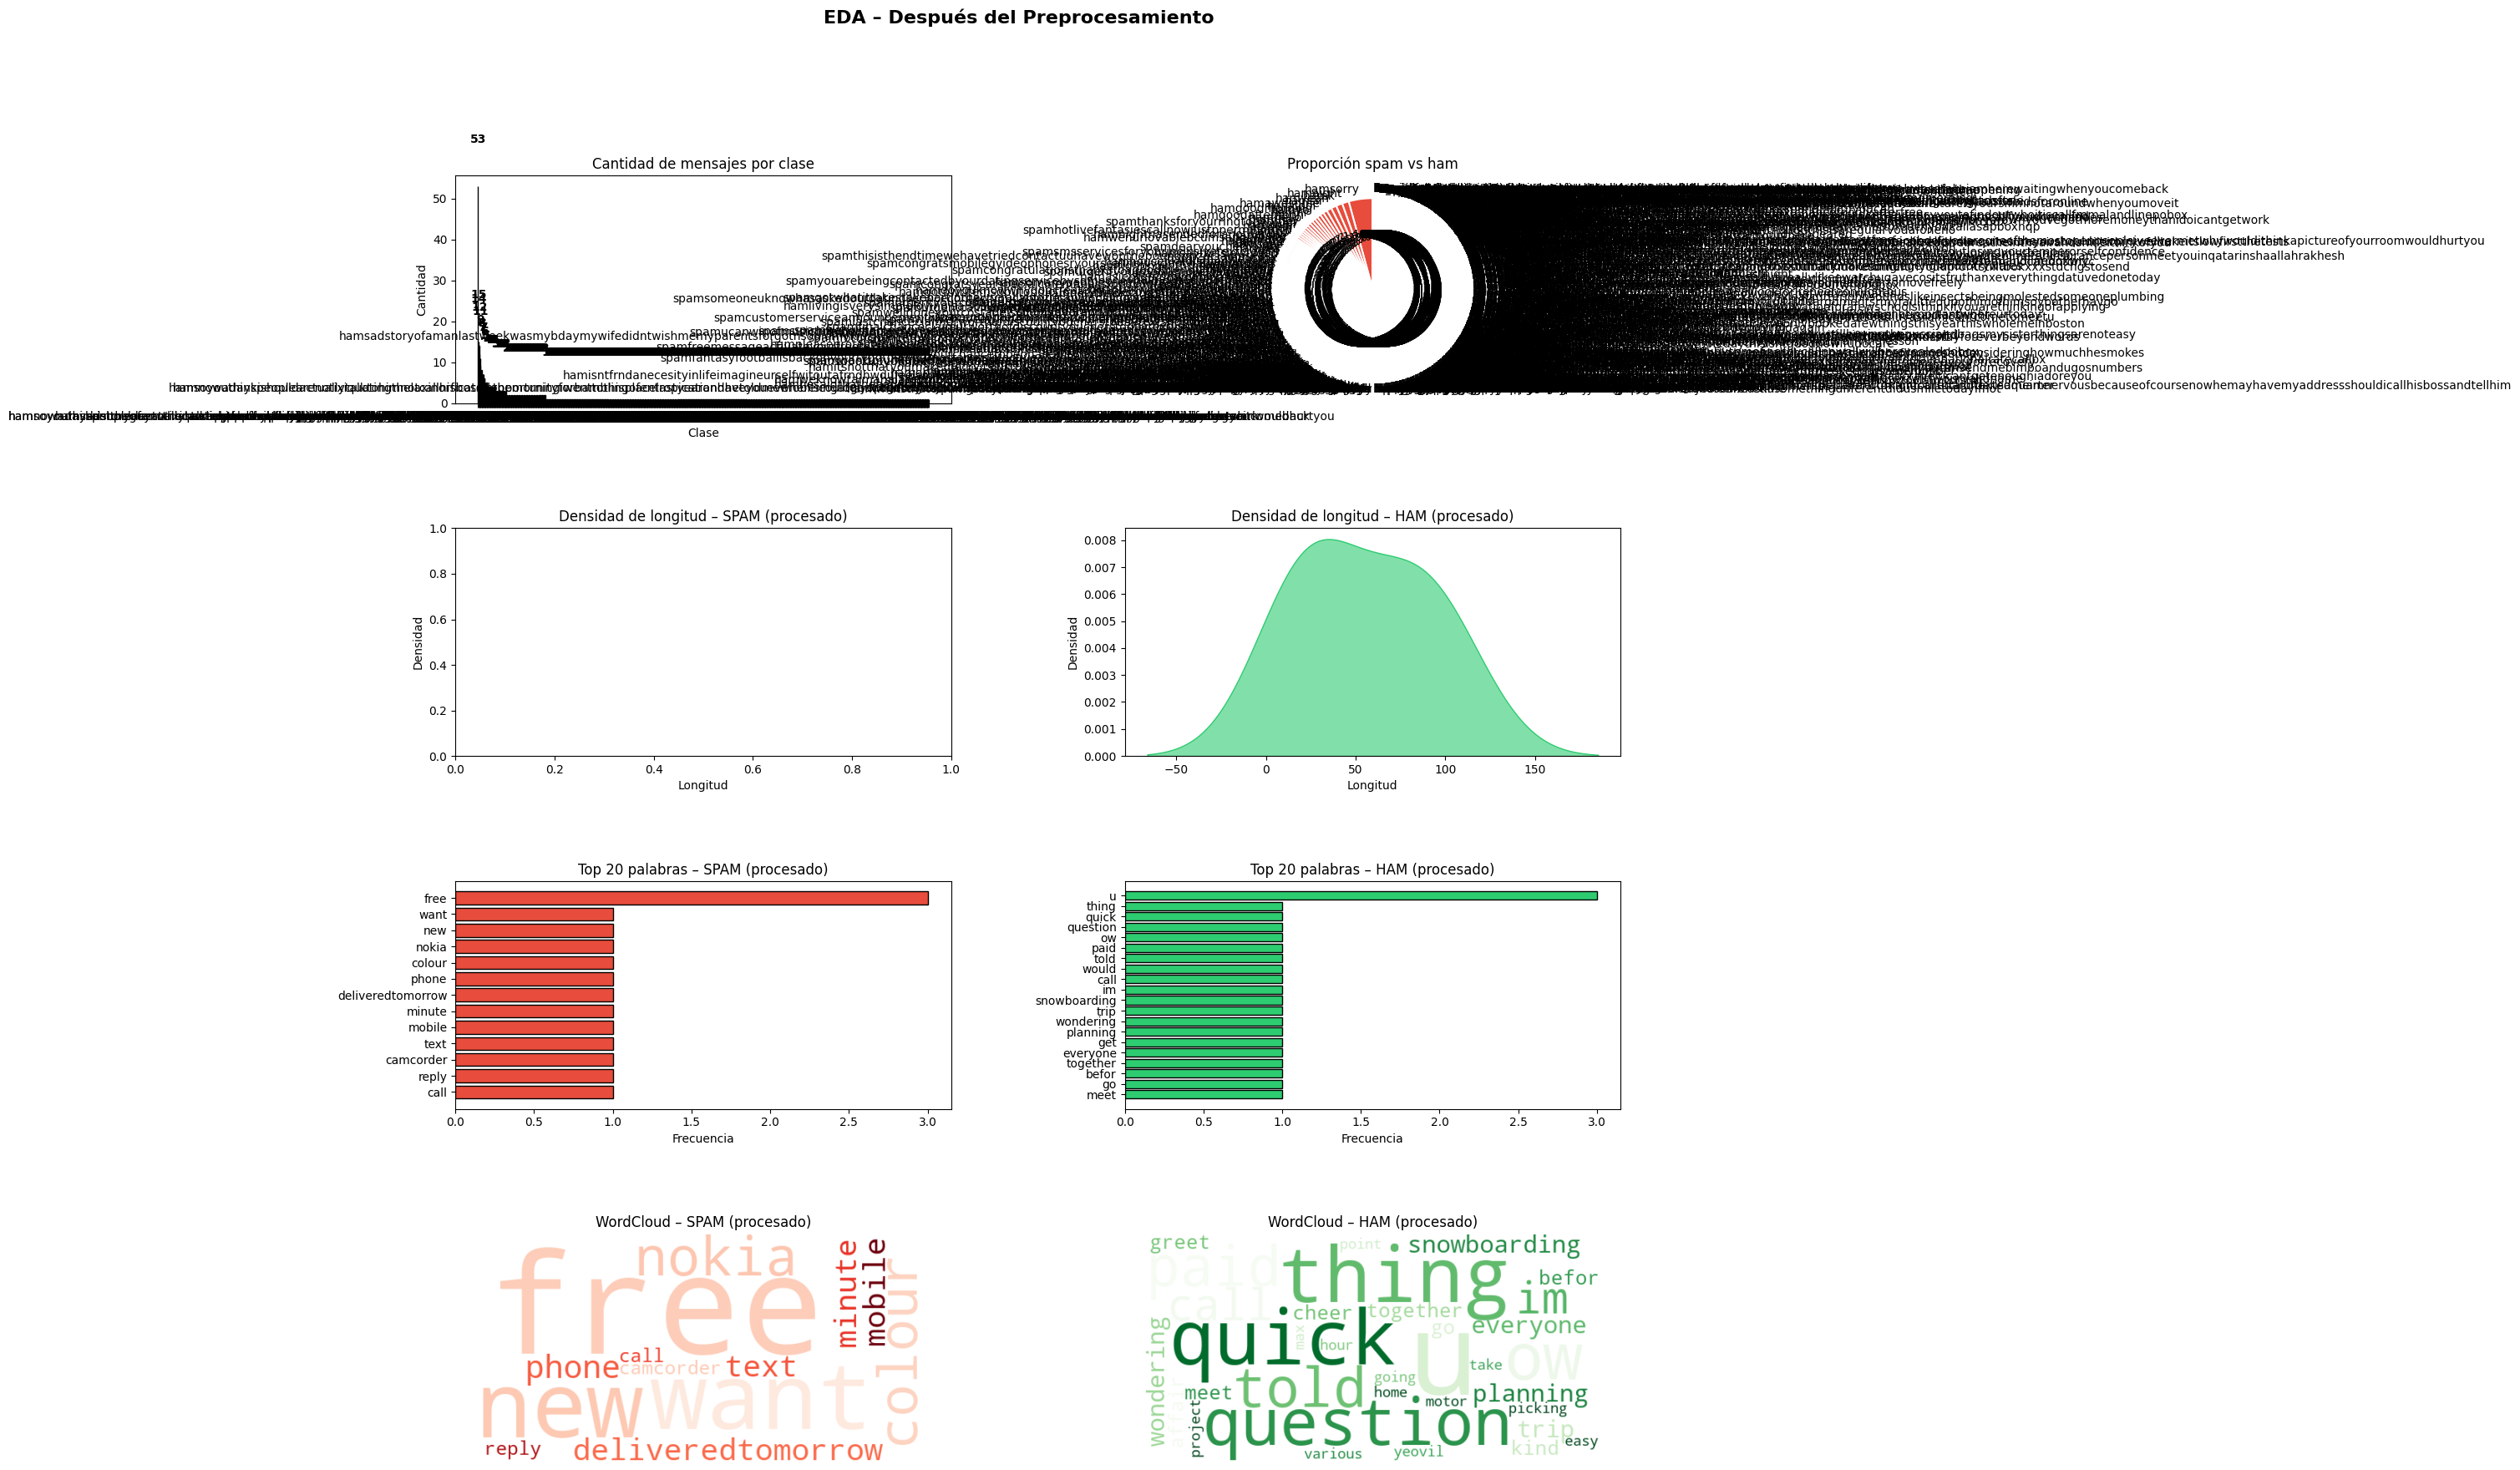

[✓] Figura 'eda_despues.png' guardada.


In [10]:
spam_proc = df[df["label"] == "spam"]
ham_proc  = df[df["label"] == "ham"]

print(f"Cantidad total de mensajes: {len(df)}")
print(df["label"].value_counts().to_string())

fig2 = plt.figure(figsize=(18, 20))
fig2.suptitle("EDA – Después del Preprocesamiento", fontsize=16, fontweight="bold", y=0.98)
gs2 = gridspec.GridSpec(4, 2, figure=fig2, hspace=0.55, wspace=0.35)

counts = df["label"].value_counts()

# (a) Cantidad por clase
ax1 = fig2.add_subplot(gs2[0, 0])
bars = ax1.bar(counts.index, counts.values,
               color=[COLOR_HAM if l == "ham" else COLOR_SPAM for l in counts.index],
               edgecolor="black", width=0.5)
ax1.set_title("Cantidad de mensajes por clase")
ax1.set_xlabel("Clase"); ax1.set_ylabel("Cantidad")
for bar, v in zip(bars, counts.values):
    ax1.text(bar.get_x() + bar.get_width() / 2, v + 10, str(v),
             ha="center", va="bottom", fontweight="bold")

# (b) Proporción
ax2 = fig2.add_subplot(gs2[0, 1])
ax2.pie(counts.values, labels=counts.index, autopct="%1.1f%%",
        colors=[COLOR_HAM if l == "ham" else COLOR_SPAM for l in counts.index],
        startangle=90, wedgeprops={"edgecolor": "white", "linewidth": 1.5})
ax2.set_title("Proporción spam vs ham")

# (c) Densidad longitud – spam (procesado)
ax3 = fig2.add_subplot(gs2[1, 0])
sns.kdeplot(spam_proc["proc_length"], ax=ax3, fill=True, color=COLOR_SPAM, alpha=0.6)
ax3.set_title("Densidad de longitud – SPAM (procesado)")
ax3.set_xlabel("Longitud"); ax3.set_ylabel("Densidad")

# (d) Densidad longitud – ham (procesado)
ax4 = fig2.add_subplot(gs2[1, 1])
sns.kdeplot(ham_proc["proc_length"], ax=ax4, fill=True, color=COLOR_HAM, alpha=0.6)
ax4.set_title("Densidad de longitud – HAM (procesado)")
ax4.set_xlabel("Longitud"); ax4.set_ylabel("Densidad")

# (e) Top 20 – spam procesado
ax5 = fig2.add_subplot(gs2[2, 0])
words_spam_p = top_words(spam_proc["processed"])
ax5.barh([w for w, _ in words_spam_p[::-1]], [c for _, c in words_spam_p[::-1]],
         color=COLOR_SPAM, edgecolor="black")
ax5.set_title("Top 20 palabras – SPAM (procesado)")
ax5.set_xlabel("Frecuencia")

# (f) Top 20 – ham procesado
ax6 = fig2.add_subplot(gs2[2, 1])
words_ham_p = top_words(ham_proc["processed"])
ax6.barh([w for w, _ in words_ham_p[::-1]], [c for _, c in words_ham_p[::-1]],
         color=COLOR_HAM, edgecolor="black")
ax6.set_title("Top 20 palabras – HAM (procesado)")
ax6.set_xlabel("Frecuencia")

# (g) WordCloud – spam procesado
ax7 = fig2.add_subplot(gs2[3, 0])
wc_spam2 = WordCloud(width=600, height=300, background_color="white",
                     colormap="Reds", max_words=100)
wc_spam2.generate(" ".join(spam_proc["processed"]))
ax7.imshow(wc_spam2, interpolation="bilinear")
ax7.axis("off"); ax7.set_title("WordCloud – SPAM (procesado)")

# (h) WordCloud – ham procesado
ax8 = fig2.add_subplot(gs2[3, 1])
wc_ham2 = WordCloud(width=600, height=300, background_color="white",
                    colormap="Greens", max_words=100)
wc_ham2.generate(" ".join(ham_proc["processed"]))
ax8.imshow(wc_ham2, interpolation="bilinear")
ax8.axis("off"); ax8.set_title("WordCloud – HAM (procesado)")

plt.savefig("eda_despues.png", dpi=150, bbox_inches="tight")
plt.show()
print("[✓] Figura 'eda_despues.png' guardada.")

---
## 5. Reflexión y Análisis


In [11]:
set_spam = {w for w, _ in top_words(spam_proc["processed"], 20)}
set_ham  = {w for w, _ in top_words(ham_proc["processed"],  20)}

comunes          = set_spam & set_ham
exclusivas_spam  = set_spam - set_ham
exclusivas_ham   = set_ham  - set_spam

print("=" * 65)
print("PALABRAS EN COMÚN (Top-20 spam ∩ Top-20 ham):")
print(comunes if comunes else "  Ninguna")

print("\nPALABRAS EXCLUSIVAS DE SPAM:")
print(exclusivas_spam)

print("\nPALABRAS EXCLUSIVAS DE HAM:")
print(exclusivas_ham)

PALABRAS EN COMÚN (Top-20 spam ∩ Top-20 ham):
{'call'}

PALABRAS EXCLUSIVAS DE SPAM:
{'new', 'free', 'want', 'reply', 'phone', 'nokia', 'text', 'colour', 'deliveredtomorrow', 'mobile', 'minute', 'camcorder'}

PALABRAS EXCLUSIVAS DE HAM:
{'meet', 'ow', 'quick', 'im', 'question', 'snowboarding', 'get', 'go', 'paid', 'wondering', 'would', 'u', 'planning', 'told', 'befor', 'thing', 'everyone', 'trip', 'together'}


### Respuestas

**¿Qué cambios son más notorios antes y después del preprocesamiento?**

- Las gráficas de densidad de longitud se desplazan hacia la izquierda: los mensajes son más cortos al eliminar stopwords y puntuación.
- Las palabras más frecuentes antes del preprocesamiento incluyen artículos y preposiciones (`the`, `to`, `a`, `I`) que desaparecen después.
- El vocabulario relevante y discriminativo queda más visible y comparable entre clases.

**¿Hay palabras en común entre spam y ham?**

Puede haber algunas palabras neutras comunes (`call`, `get`, `know`), pero la mayoría del Top-20 es distinto entre clases.

**¿Qué palabras son exclusivas de cada clase?**

- **SPAM:** palabras de urgencia, premios y dinero → `free`, `call`, `win`, `prize`, `claim`, `txt`, `urgent`, `mobile`, `cash`
- **HAM:** vocabulario cotidiano y personal → `ok`, `good`, `come`, `home`, `time`, `love`, `got`, `will`, `day`

**¿Qué características del texto podrían ser útiles para clasificar?**

1. **Longitud del mensaje** — spam tiende a ser más largo.
2. **Palabras de urgencia/oferta** — `free`, `win`, `prize`, `claim`, `urgent`.
3. **Presencia de números de teléfono o URLs.**
4. **Proporción de mayúsculas** en el texto original.
5. **Distribución de frecuencias de palabras** (Bag-of-Words / TF-IDF) como feature para un clasificador.
